# Transverse Field Ising Model (TFIM) evolution using Pauli Propagation

I've written a Julia module, `pauli_propagation_functions.jl`, based on the paper “*Pauli Propagation: A Computational Framework for Simulating Quantum Systems*” and the associated package `PauliPropagation.jl`. This module allows me to handle propagation through a quantum circuit by using the **Pauli string decomposition** of an operator.

To test the package, we'll first focus on a simple, well-understood system to validate the method and develop our intuition before moving on to more complex circuits in future notebooks.

In [226]:
# using Pkg; Pkg.add("PauliPropagation")

In [227]:
using PauliPropagation

using LinearAlgebra
using Plots

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# 1. Introduction

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates U** applied in a **bricklayer pattern**.

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

We will discretize the time, and a layer is applied every $dt=0.1$ time step.

In [228]:
dt = 0.1

# Brick layer topology exemple
nqubits = 4
topology = bricklayertopology(nqubits; periodic=false)

3-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (3, 4)
 (2, 3)

Each layer consists of **nearest-neighbor gates** of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ which is, in our case $dt$, a fixed parameter (Trotter step).


This type of circuit corresponds to a **Trotterized time evolution** under an **TFIM Hamiltonian**:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

$i$ and $j$ are the topological tuples $(i, j)$, so they are the nearest neighbors here

In [229]:
function TFIM_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
      topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      rxxlayer!(circuit, topology)
    end
    return circuit
end

TFIM_circuit (generic function with 1 method)

In [230]:
# Circuit exemple
nlayers = 5
circuit = TFIM_circuit(nqubits, nlayers; topology)
parameters = ones(countparameters(circuit)) * dt # all the \theta are dt

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 15


---

## 1.1 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [231]:
# Observable exemple
Z_2 = PauliString(nqubits, :Z, 2) # IZI...I
observable = Z_2

PauliString(nqubits: 4, 1.0 * IZII)

---

## 1.2 Pauli propagation method

The key idea of **Pauli propagation** is to express the observable as a **sum of Pauli strings**:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

$P_\alpha$ a Pauli string is a tensor product of $\{I, X, Y, Z\}$, the Pauli matrices.

Exemple :
- for 5 qubits, it can be $X\otimes I \otimes Y\otimes I \otimes I$

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings (and we call this type of object : `PauliSum`). This leads to a growth in the number of terms, which is controlled in practice using:

- **truncation of small coefficients** (if $c_\alpha < $ `min_abs_coeff` we truncate him)
- **limitation of the Pauli weight** (if $P_\alpha$ contains more than `max_weight` non identity Pauli matrices, we delete him)

This method is particularly efficient when the operator remains relatively **sparse in the Pauli basis**.

In [232]:
# truncations exemple
max_weight = 3 # the max is nqubits
min_abs_coeff = 1e-4

0.0001

So propagating a Pauli string through a circuit transforms it into a Pauli sum.

We can use the `propagate` function from the package directly, but in the rest of this notebook we will use my `propagate_layerbylayer` function, which allows us to **calculate the evolution** of some physical quantity.

In [233]:
# propagation exemple
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 4, 4 Pauli terms:
 -0.22985 * XZXI
 0.42074 * XYII
 0.77015 * IZII
 0.42074 * IYXI
)

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the **norm of the observable**, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [234]:
norm = pp.pauli_norm(pauli_sum)

1.0000000000000013

---

# 2. Quantities and measurements

## 2.1 Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha |c_\alpha|^2 log(|c_\alpha|^2)$$

In [235]:
entropy = pp.pauli_entropy(pauli_sum)

1.0781872743987904

---

## 2.2 Overlap with the intial state $|0\rangle$

To test the method, we will examine the evolution of a physical quantity called the overlap, which is a trace between the operator and the density operator.

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha$, the pauli string $P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [236]:
function compute_overlap(pauli_sum::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in pauli_sum
      string = pp.decode_pauli(pauli_string, pauli_sum.nqubits) # give the pauli string P_\alpha like "IXIZ"
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_overlap (generic function with 1 method)

But in this package we have a function `overlapwithzero()` which does exactly the same thing :

In [237]:
overlap1 = compute_overlap(pauli_sum)
overlap2 = overlapwithzero(pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

# 3. Verification of the correct implementation of the method

## 3.1 Initialisation for the PauliPropagation method

Initialisation of the circuit :

In [238]:
nqubits = 9
topology = bricklayertopology(nqubits; periodic=false)

nlayers = 150
circuit = TFIM_circuit(nqubits, nlayers; topology)

parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value dt

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 1200


Initialisation of the observable as a Pauli string

In [239]:
i = 2
Z_i_pauliString = PauliString(nqubits, :Z, i) # IZI...I
observable = Z_i_pauliString

PauliString(nqubits: 9, 1.0 * IZIIIIIII)

---

## 3.2 Propagation with the PauliPropagation method

Next, we will verify our method by comparing the time-dependent overlap of a $\psi_0$ state ($\langle \psi_0 | \hat O(t) | \psi_0\rangle$) with the exact method. Therefore, we need to pass this information to the `propagate_layerbylayer` function.

In [240]:
ψ0 = append!([1.],[0. for _ in 2:(2^nqubits)])

max_weight = typemax(Int)   # no limit
min_abs_coeff = 0.0         # no truncations

Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

# we compute the matrix form of the pauli sum
Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.00468897819519043 seconds


512×512 Matrix{ComplexF64}:
 0.577126+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im  0.577126+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
         ⋮                       ⋱           ⋮       
      0.0+0.0im      

---

## 3.3 Exact method

We can calculate the same circuit analytically and compare our results :

In [241]:
Z_i = ext.get_Zi(nqubits, i)
circuit_exact = ext.circuit_TFIM(nqubits, dt, nlayers)

Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i; ψ0)

Zi_t_exact

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 20.907169103622437 seconds


512×512 Matrix{ComplexF64}:
     0.577126+0.0im          …           0.0+0.0im
          0.0+0.0im             -3.42904e-16+0.0im
          0.0+0.0im                      0.0-3.67613e-16im
          0.0+5.34058e-16im              0.0+0.0im
          0.0+0.0im              5.32055e-16+0.0im
  6.68039e-16+0.0im          …           0.0+0.0im
          0.0-1.89109e-15im              0.0+0.0im
          0.0+0.0im                      0.0+1.72025e-15im
          0.0+0.0im                      0.0+1.58526e-16im
          0.0-1.56115e-15im              0.0+0.0im
 -4.85246e-17+0.0im          …           0.0+0.0im
          0.0+0.0im              4.85987e-16+0.0im
          0.0-2.00363e-15im              0.0+0.0im
             ⋮               ⋱  
 -1.88586e-16+0.0im          …           0.0+0.0im
          0.0+0.0im              9.95731e-16+0.0im
          0.0+0.0im                      0.0+6.61004e-16im
          0.0-2.19056e-16im              0.0+0.0im
          0.0-2.15674e-15im             

---

## 3.4 Result

In [242]:
is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  8.348426143624658e-14


We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-14}$ with $150$ evolution steps.

Numerical error is calculate with the LinearAlgebra.jl function, `opnorm(A)`, corresponding to the spectral norm :
$$||A||_2 = \sqrt{\lambda_{max} (A^\dagger A) } = \sigma_{max}(A) $$

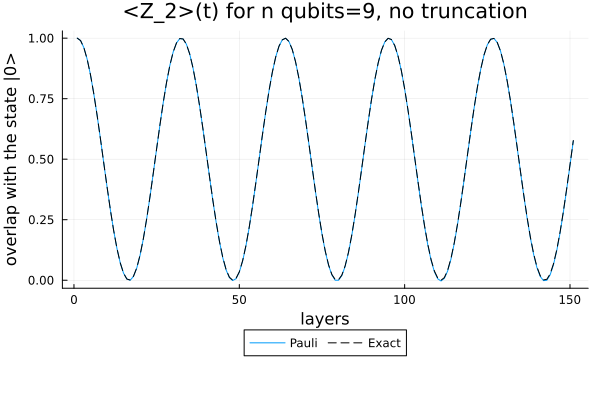

In [254]:
overlap_pp = result_pp["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, overlap_pp, label="Pauli", line = (1, :solid))
plot!(p, overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

We obtain the same curve along the $150$ evolution steps.

---

# 4. Truncations test

## 4.1 Max Weight

In [244]:
max_weight_list = 1:3
min_abs_coeff_idx = 4
min_abs_coeff = 10. ^(-min_abs_coeff_idx)

overlap_max_weight, norm_max_weight = Vector{Float64}[], Vector{Float64}[]
for max_weight in max_weight_list
  println("---")
  println("Max weight = ", max_weight)
  # propagation
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

  # result
  push!(overlap_max_weight, result_pp["overlap"])
  push!(norm_max_weight, result_pp["norm"])

  # print difference between Zi(t)
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)
  is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
  println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)
  error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
  println("with an error of :  ", error_val)
end

---
Max weight = 1
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0034470558166503906 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  1.300575680314241
---
Max weight = 2
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003690004348754883 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  2.171633680422867
---
Max weight = 3
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150

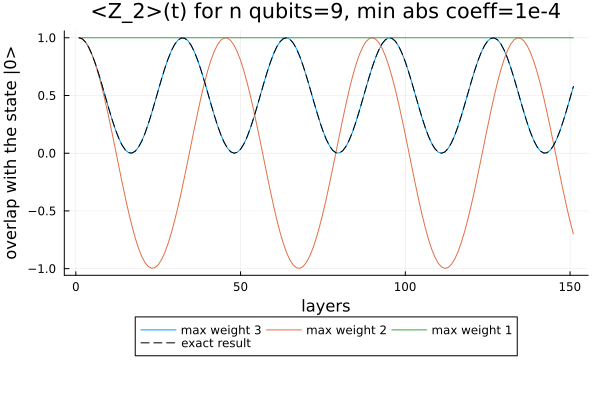

In [245]:
p = plot(title="<Z_$i>(t) for n qubits=$nqubits, min abs coeff=1e-$min_abs_coeff_idx", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_max_weight))
    plot!(p, 1:length(overlap), overlap, label="max weight $(reverse(max_weight_list)[i])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="exact result", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=length(overlap_max_weight))

display(p)

### Observation

We observe that for a maximum weight below 3, our method troncate $c_\alpha$ wich are important for the physical state, we lost informations.


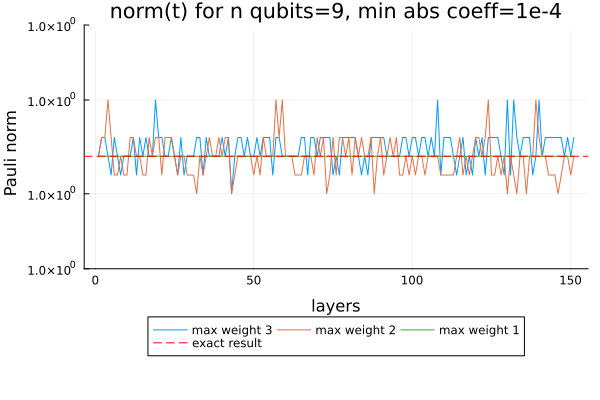

In [246]:
dy = 1e-15
p = plot(title="norm(t) for n qubits=$nqubits, min abs coeff=1e-$min_abs_coeff_idx", xlabel="layers", ylabel="Pauli norm",ylims=(1-dy,1+dy))

for (i, norm) in enumerate(reverse(norm_max_weight))
    plot!(p, 1:length(norm), norm, label="max weight $(reverse(max_weight_list)[i])")
end
hline!([1], label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(norm_max_weight))

display(p)

The norm remains close to 1, with a numerical error of $10^{-15}$.

---

## 4.2 Min abs coeff

In [247]:
max_weight = 3
min_abs_coeff_idx = round.(Int, range(1, 3))
min_abs_coeff_list = 10.0 .^ .-min_abs_coeff_idx

overlap_min_abs_coeff, norm_min_abs_coeff = Vector{Float64}[], Vector{Float64}[]
for (i, min_abs_coeff) in enumerate(min_abs_coeff_list)
  println("---")
  println("Min abs coeff = 1e-", min_abs_coeff_idx[i])
  # propagation
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)

  # result
  push!(overlap_min_abs_coeff, result_pp["overlap"])
  push!(norm_min_abs_coeff, result_pp["norm"])

  # print difference between Zi(t)
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)
  is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
  println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)
  error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
  println("with an error of :  ", error_val)
end

---
Min abs coeff = 1e-1
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0033419132232666016 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  1.300575680314241
---
Min abs coeff = 1e-2
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003654956817626953 seconds
Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  0.0268170667071707
---
Min abs coeff = 1e-3
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 comp

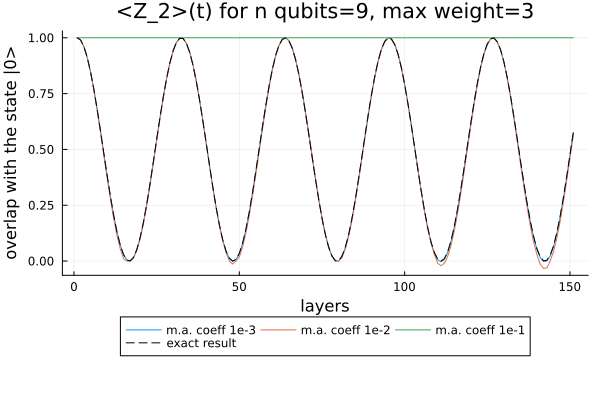

In [248]:
p = plot(title="<Z_$i>(t) for n qubits=$nqubits, max weight=$max_weight", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_min_abs_coeff))
    plot!(p, 1:length(overlap), overlap, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
plot!(p, 1:length(overlap_exact), overlap_exact, label="exact result", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=length(overlap_min_abs_coeff))

display(p)


### Observation

It is clear that we need a value smaller or equal than $10^{-3}$ for this circuit and this number of qubits.

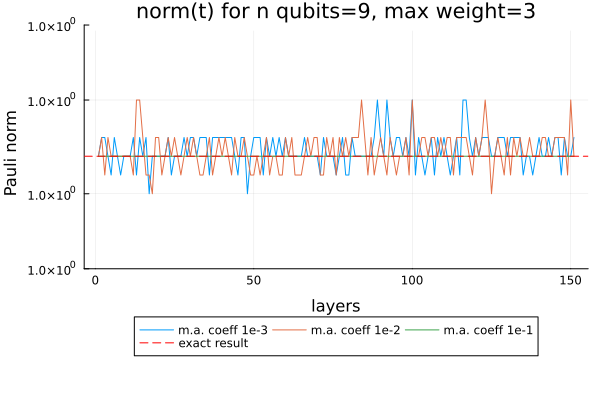

In [249]:
dy = 1e-15
p = plot(title="norm(t) for n qubits=$nqubits, max weight=$max_weight", xlabel="layers", ylabel="Pauli norm",ylims=(1-dy,1+dy))

for (i, norm) in enumerate(reverse(norm_min_abs_coeff))
    plot!(p, 1:length(norm), norm, label="m.a. coeff 1e-$(reverse(min_abs_coeff_idx)[i])")
end
hline!([1], label="exact result", line = (1, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=length(norm_min_abs_coeff))

display(p)

The norm remains close to 1, with a numerical error of $10^{-15}$.

---

# 5. Conclusion

We can now propagate our observable through our circuit using truncations optimized for our problem.

layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0033638477325439453 seconds


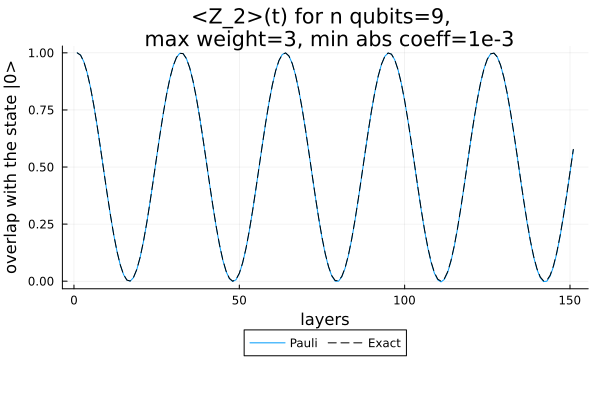

In [250]:
max_weight = 3
min_abs_coeff_idx = 3
min_abs_coeff = 10. ^(-min_abs_coeff_idx)

Zi_t_pauli_propagation, result = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters; max_weight, min_abs_coeff, ψ0)
overlap_mpo = result["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, \n max weight=$max_weight, min abs coeff=1e-$min_abs_coeff_idx", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(overlap_mpo), overlap_mpo, label="Pauli")
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)

plot!(legend=:outerbottom, legendcolumns=2)

display(p)

The Pauli Sum that we optain at the end with the Pauli propagation, $Z_2(t_{final})$ :

In [251]:
Zi_t_pauli_propagation

PauliSum(nqubits: 9, 4 Pauli terms:
 -0.42052 * XZXIIIIII
 -0.49602 * XYIIIIIII
 0.5755 * IZIIIIIII
 -0.4959 * IYXIIIIII
)

In [252]:
matrix = pp.compute_matrix(Zi_t_pauli_propagation)
tol = 1e-2
println("Z_$i (t_final) are close for the two methods (with a tolerance=$tol) ? ", isapprox(Zi_t_exact, matrix; rtol=tol))

Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true


We can see that for this type of circuit, our **result remains very close with weak truncations**, the result is close to the exact with a tolerance of $10^{-2}$.

This close result is because the **Pauli strings do not become complex in this type of circuit**, so truncation has very little effect, which prevents our results from diverging from the case without truncation.

The **Pauli propagation method works very well in this case** and **saves us significant computation time** compared to the exact method,
- **Exact method:** 25.04 sec
- **Pauli method:** 0.00304 sec

Which is no small advantage.

---

# Annexe

### Plot of the Pauli entropy

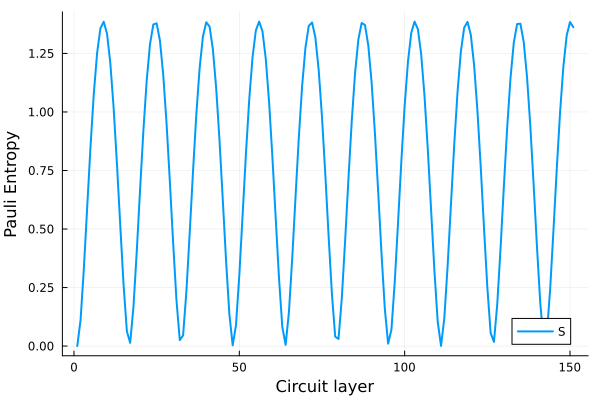

In [253]:
entropy = result_pp["S"]
plot(entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)